# Validación de Curvas — Diseño Factorial 3² con Ventilador Hamilton S1

Compara las curvas dinámicas de Presión, Flujo y Volumen del simulador numérico contra
las mediciones del ventilador mecánico Hamilton S1, usando datos capturados en el
laboratorio Vesalius (Universidad EIA) con el simulador pulmonar mecánico Ingmar Medical
(modelo 20.00.000, dos compartimentos).

**Diseño experimental:** factorial 3² (Compliance × Resistencia), 3 réplicas, 27 corridas.
**Modo:** VCV flujo cuadrado, Vt=500 mL, PEEP=5 cmH₂O, FR=15 rpm, I:E=1:2.
**Métricas:** RMSE por variable, CCC (Lin), Bland-Altman sobre PIP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

In [2]:
def calcular_ccc(y_true, y_pred):
    """Coeficiente de Correlación de Concordancia de Lin."""
    cor = np.corrcoef(y_true, y_pred)[0, 1]
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    sd_true, sd_pred = np.std(y_true), np.std(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    numerador = 2 * cor * sd_true * sd_pred
    denominador = var_true + var_pred + (mean_true - mean_pred) ** 2
    return float(numerador / denominador)

In [3]:
class Paciente:
    def __init__(self, R1=5, C1=0.05, R2=10, C2=0.05):
        self.R1 = R1
        self.C1 = C1
        self.R2 = R2
        self.C2 = C2
        self.E1 = 1 / self.C1
        self.E2 = 1 / self.C2


class Ventilador:
    def __init__(self, modo='PCV', PEEP=5.0, P_driving=15.0, fr=20.0, Ti=1.0, Vt=None):
        self.modo = modo
        self.PEEP = PEEP
        self.P_driving = P_driving
        self.fr = fr
        self.Ti = Ti
        self.T_total = 60.0 / fr
        self.Vt = Vt
        if modo == 'VCV':
            assert Vt is not None, "Se requiere Vt para modo VCV"
            self.flow_insp = Vt / Ti
        else:
            self.flow_insp = None

    def presion(self, t):
        t_arr = np.asarray(t)
        en_insp = (t_arr % self.T_total) < self.Ti
        if self.modo == 'PCV':
            return np.where(en_insp, self.PEEP + self.P_driving, self.PEEP)
        elif self.modo == 'VCV':
            return np.full_like(t_arr, self.PEEP)
        else:
            raise ValueError(f"Modo desconocido: {self.modo}")

    def flujo(self, t):
        if self.modo != 'VCV':
            return np.zeros_like(np.asarray(t))
        t_arr = np.asarray(t)
        return np.where((t_arr % self.T_total) < self.Ti, self.flow_insp, 0.0)


class Simulador:
    def __init__(self, paciente, ventilador, control=None):
        self.paciente = paciente
        self.ventilador = ventilador
        self.control = control

    def _edo_insp(self, t, y):
        V1, V2 = y
        pac, vent = self.paciente, self.ventilador
        if vent.modo == 'VCV':
            flow = vent.flow_insp
            P_aw = (flow + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        else:
            P_aw = vent.PEEP + vent.P_driving
        return [(P_aw - pac.E1*V1)/pac.R1, (P_aw - pac.E2*V2)/pac.R2]

    def _edo_esp(self, t, y):
        V1, V2 = y
        pac, vent = self.paciente, self.ventilador
        R_exp = 5.0
        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        return [(A*(pac.R2+R_exp) - B*R_exp)/D, (B*(pac.R1+R_exp) - A*R_exp)/D]

    def simular(self, num_ciclos=15, pasos_por_ciclo=100):
        t_data, V1_data, V2_data = [], [], []
        V0 = [0.0, 0.0]
        for i in range(num_ciclos):
            t0   = i * self.ventilador.T_total
            t_Ti = t0 + self.ventilador.Ti
            t1   = t0 + self.ventilador.T_total
            n_insp = max(10, int(pasos_por_ciclo * self.ventilador.Ti / self.ventilador.T_total))
            n_esp  = max(10, pasos_por_ciclo - n_insp)
            t_eval_i = np.linspace(t0, t_Ti, n_insp, endpoint=False)
            sol_i = solve_ivp(self._edo_insp, [t0, t_Ti], V0,
                              t_eval=t_eval_i, method='RK45', max_step=0.05)
            V_mid = sol_i.y[:, -1]
            t_eval_e = np.linspace(t_Ti, t1, n_esp, endpoint=(i == num_ciclos-1))
            sol_e = solve_ivp(self._edo_esp, [t_Ti, t1], V_mid,
                              t_eval=t_eval_e, method='RK45', max_step=0.05)
            t_data.extend([sol_i.t, sol_e.t])
            V1_data.extend([sol_i.y[0], sol_e.y[0]])
            V2_data.extend([sol_i.y[1], sol_e.y[1]])
            V0 = sol_e.y[:, -1]
        return np.concatenate(t_data), np.concatenate(V1_data), np.concatenate(V2_data)

    def procesar_resultados(self, t, V1, V2):
        Vt = V1 + V2
        R_exp = 5.0
        pac, vent = self.paciente, self.ventilador
        en_insp = (t % vent.T_total) < vent.Ti

        flow_ctrl = vent.flow_insp * np.ones_like(t)
        P_aw_i = (flow_ctrl + pac.E1*V1/pac.R1 + pac.E2*V2/pac.R2) / (1/pac.R1 + 1/pac.R2)
        f1_i = (P_aw_i - pac.E1*V1) / pac.R1
        f2_i = (P_aw_i - pac.E2*V2) / pac.R2

        A = vent.PEEP - pac.E1*V1
        B = vent.PEEP - pac.E2*V2
        D = pac.R1*pac.R2 + pac.R1*R_exp + pac.R2*R_exp
        f1_e = (A*(pac.R2+R_exp) - B*R_exp) / D
        f2_e = (B*(pac.R1+R_exp) - A*R_exp) / D

        flujo1 = np.where(en_insp, f1_i, f1_e)
        flujo2 = np.where(en_insp, f2_i, f2_e)
        flujo_total = flujo1 + flujo2

        P_aw_esp = vent.PEEP - flujo_total * R_exp
        P_aw = np.where(en_insp, P_aw_i, P_aw_esp)

        return {'t': t, 'V1': V1, 'V2': V2, 'Vt': Vt,
                'flow1': flujo1, 'flow2': flujo2, 'flow': flujo_total, 'P_aw': P_aw}

In [4]:
# Rutas
BASE      = "../../"
DATOS_DIR = BASE + "JulianQ/"

# Parámetros del experimento (fijados en todas las corridas)
FR      = 15.0
T_TOTAL = 60.0 / FR       # 4.0 s
TI      = T_TOTAL / 3.0   # 1.333 s  (I:E = 1:2)
VT      = 0.5             # L
PEEP    = 5.0             # cmH₂O

NUM_CICLOS_SIM  = 10
PASOS_POR_CICLO = 400

# Cargar la matriz del experimento (encoding latin-1 / Windows-1252)
df_exp = pd.read_csv(BASE + "matriz_experimento_ventilador.csv", sep=';', index_col=0,
                     encoding='latin-1')
df_exp.columns = df_exp.columns.str.strip()
df_exp = df_exp.rename(columns={
    'Medici\xf3n Compliance': 'C_medido',
    'Medici\xf3n Resistencia': 'R_medido',
})
# Fallback: si los nombres ya llegaron limpios, renombrar por posición
if 'C_medido' not in df_exp.columns:
    cols = list(df_exp.columns)
    df_exp = df_exp.rename(columns={cols[2]: 'C_medido', cols[3]: 'R_medido'})

# Construir nombre de archivo desde la columna Hora  (formato HH:MM → HH-MM)
def hora_a_filename(hora):
    h, m = hora.strip().split(':')
    return f"hm_Waveform 26-05-08-{h}-{m}.txt"

df_exp['archivo'] = df_exp['Hora'].apply(hora_a_filename)
# Corrección puntual: la corrida con hora '15:47' corresponde al archivo '15-46'
df_exp.loc[df_exp['Hora'].str.strip() == '15:47', 'archivo'] = 'hm_Waveform 26-05-08-15-46.txt'

print(df_exp[['Compliance', 'Resistencia', 'C_medido', 'R_medido', 'Hora', 'archivo']].to_string())

   Compliance Resistencia  C_medido  R_medido   Hora                         archivo
z                                                                                   
1        Alta        Alta        62        20  15:13  hm_Waveform 26-05-08-15-13.txt
2       Media       Media        49        15  15:16  hm_Waveform 26-05-08-15-16.txt
3        Baja        Baja        42         2  15:26  hm_Waveform 26-05-08-15-26.txt
4       Media        Baja        51         4  15:29  hm_Waveform 26-05-08-15-29.txt
5        Baja        Baja        43         3  15:32  hm_Waveform 26-05-08-15-32.txt
6        Baja        Alta        35        17  15:35  hm_Waveform 26-05-08-15-35.txt
7        Alta       Media        60        11  15:40  hm_Waveform 26-05-08-15-40.txt
8        Alta        Alta        58        20  15:43  hm_Waveform 26-05-08-15-43.txt
9       Media        Baja        47         5  15:47  hm_Waveform 26-05-08-15-46.txt
10       Alta        Baja        64         5  15:49  hm_Waveform

In [5]:
def cargar_ciclo_ventilador(filepath):
    """
    Carga el último ciclo completo (inspiración + espiración) de un archivo
    de datalogger Hamilton S1.

    Devuelve (t, P, F, V) donde:
        t : tiempo en segundos, normalizado a 0 al inicio del ciclo
        P : Paw en cmH₂O
        F : flujo en L/s  (positivo = inspiración)
        V : volumen en L   (referencia = 0 al inicio del ciclo, como lo registra Hamilton)
    """
    df = pd.read_csv(filepath, sep='\t', skiprows=2, encoding='latin-1')
    df.columns = df.columns.str.strip()

    breath_nums = sorted(df['Breath'].unique())
    UMBRAL = 5.0  # l/min — umbral para considerar flujo inspiratorio/espiratorio real

    # Recorrer de mayor a menor: el último ciclo completo es suficiente
    for b in reversed(breath_nums):
        ciclo = df[df['Breath'] == b].copy()
        tiene_insp = (ciclo['Flow (l/min)'] >  UMBRAL).any()
        tiene_esp  = (ciclo['Flow (l/min)'] < -UMBRAL).any()
        if tiene_insp and tiene_esp:
            t0_ms = ciclo['Time(ms)'].iloc[0]
            t = (ciclo['Time(ms)'].values - t0_ms) / 1000.0       # s
            P = ciclo['Paw (cmH2O)'].values.astype(float)
            F = ciclo['Flow (l/min)'].values.astype(float) / 60.0  # L/s
            V = ciclo['Volume (ml)'].values.astype(float) / 1000.0  # L
            return t, P, F, V

    raise ValueError(f"No se encontró ciclo completo en {filepath}")

In [6]:
def simular_ciclo_vcv(R_medido, C_medido_mL):
    """
    Corre el simulador en modo VCV con los parámetros del experimento y
    devuelve el último ciclo en régimen permanente.

    Mapeo de parámetros (2 compartimentos en paralelo, niveles iguales):
        C1 = C2 = C_total / 2          (L/cmH₂O)
        R1 = R2 = 2 × R_total          (cmH₂O·s/L)

    Devuelve (t, P, F, V) con t normalizado a 0 y V referenciada al inicio del ciclo.
    """
    C1 = C2 = (C_medido_mL / 1000.0) / 2.0   # mL/cmH₂O → L/cmH₂O, dividido en 2
    R1 = R2 = 2.0 * R_medido                   # factor 2 por paralelo simétrico

    paciente   = Paciente(R1=R1, C1=C1, R2=R2, C2=C2)
    ventilador = Ventilador(modo='VCV', PEEP=PEEP, fr=FR, Ti=TI, Vt=VT)
    sim        = Simulador(paciente, ventilador)

    t_arr, V1_arr, V2_arr = sim.simular(num_ciclos=NUM_CICLOS_SIM, pasos_por_ciclo=PASOS_POR_CICLO)
    res = sim.procesar_resultados(t_arr, V1_arr, V2_arr)

    # Extraer último ciclo
    t_inicio = (NUM_CICLOS_SIM - 1) * T_TOTAL
    mask = t_arr >= t_inicio
    t_sim  = t_arr[mask] - t_inicio           # normalizado a 0
    P_sim  = res['P_aw'][mask]
    F_sim  = res['flow'][mask]
    Vt_sim = res['Vt'][mask] - res['Vt'][mask][0]  # referencia al inicio del ciclo (=0)

    return t_sim, P_sim, F_sim, Vt_sim

In [7]:
resultados   = []
datos_ejemplo = {}   # primer escenario Media/Media, para graficar series de tiempo

for idx, fila in df_exp.iterrows():
    R    = fila['R_medido']
    C    = fila['C_medido']
    comp = fila['Compliance']
    res  = fila['Resistencia']
    ruta = DATOS_DIR + fila['archivo']

    # ── Datos ventilador físico ─────────────────────────────────────────────
    t_fis, P_fis, F_fis, V_fis = cargar_ciclo_ventilador(ruta)

    # ── Datos simulador ─────────────────────────────────────────────────────
    t_sim, P_sim, F_sim, V_sim = simular_ciclo_vcv(R, C)

    # ── Cuadrícula temporal común (pasos de 32 ms) ──────────────────────────
    t_max  = min(t_fis[-1], t_sim[-1])
    t_com  = np.arange(0.032, t_max - 0.032, 0.032)

    def interp(t_src, y_src, t_dst):
        return interp1d(t_src, y_src, bounds_error=False,
                        fill_value=(y_src[0], y_src[-1]))(t_dst)

    P_fis_c = interp(t_fis, P_fis, t_com)
    F_fis_c = interp(t_fis, F_fis, t_com)
    V_fis_c = interp(t_fis, V_fis, t_com)
    P_sim_c = interp(t_sim, P_sim, t_com)
    F_sim_c = interp(t_sim, F_sim, t_com)
    V_sim_c = interp(t_sim, V_sim, t_com)

    # ── Métricas de waveform ─────────────────────────────────────────────────
    rmse_P = rmse(P_fis_c, P_sim_c)
    rmse_F = rmse(F_fis_c, F_sim_c)
    rmse_V = rmse(V_fis_c, V_sim_c)
    ccc_P  = calcular_ccc(P_fis_c, P_sim_c)
    ccc_F  = calcular_ccc(F_fis_c, F_sim_c)
    ccc_V  = calcular_ccc(V_fis_c, V_sim_c)

    # ── Métricas escalares (para Bland-Altman) ───────────────────────────────
    PIP_fis   = float(np.max(P_fis_c))
    PIP_sim   = float(np.max(P_sim_c))
    Qpico_fis = float(np.max(F_fis_c))    # L/s, pico inspiratorio
    Qpico_sim = float(np.max(F_sim_c))
    VT_fis    = float(np.max(V_fis_c))    # L, volumen tidal (máx del ciclo)
    VT_sim    = float(np.max(V_sim_c))

    resultados.append({
        'Orden': idx, 'Compliance': comp, 'Resistencia': res,
        'C_medido': C, 'R_medido': R,
        'RMSE_P': rmse_P, 'RMSE_F': rmse_F, 'RMSE_V': rmse_V,
        'CCC_P':  ccc_P,  'CCC_F':  ccc_F,  'CCC_V':  ccc_V,
        'PIP_fis': PIP_fis, 'PIP_sim': PIP_sim,
        'Qpico_fis': Qpico_fis, 'Qpico_sim': Qpico_sim,
        'VT_fis': VT_fis, 'VT_sim': VT_sim,
    })

    # Guardar el primer escenario Media/Media para graficar
    if comp == 'Media' and res == 'Media' and not datos_ejemplo:
        datos_ejemplo = {
            't': t_com,
            'P_fis': P_fis_c, 'F_fis': F_fis_c, 'V_fis': V_fis_c,
            'P_sim': P_sim_c, 'F_sim': F_sim_c, 'V_sim': V_sim_c,
            'R': R, 'C': C,
        }

    print(f"Corrida {idx:2d}  {comp:6s}/{res:6s}  C={C:3d} mL/cmH₂O  R={R:2d} cmH₂O·s/L"
          f"  │  RMSE_P={rmse_P:.3f}  CCC_P={ccc_P:.3f}")

df_res = pd.DataFrame(resultados)
print("\n── Resumen global ─────────────────────────────────────────────────────")
print(df_res[['RMSE_P','RMSE_F','RMSE_V','CCC_P','CCC_F','CCC_V']].describe().round(4))


Corrida  1  Alta  /Alta    C= 62 mL/cmH₂O  R=20 cmH₂O·s/L  │  RMSE_P=2.249  CCC_P=0.930
Corrida  2  Media /Media   C= 49 mL/cmH₂O  R=15 cmH₂O·s/L  │  RMSE_P=2.680  CCC_P=0.861
Corrida  3  Baja  /Baja    C= 42 mL/cmH₂O  R= 2 cmH₂O·s/L  │  RMSE_P=1.192  CCC_P=0.954
Corrida  4  Media /Baja    C= 51 mL/cmH₂O  R= 4 cmH₂O·s/L  │  RMSE_P=1.543  CCC_P=0.898
Corrida  5  Baja  /Baja    C= 43 mL/cmH₂O  R= 3 cmH₂O·s/L  │  RMSE_P=1.894  CCC_P=0.887
Corrida  6  Baja  /Alta    C= 35 mL/cmH₂O  R=17 cmH₂O·s/L  │  RMSE_P=1.711  CCC_P=0.965
Corrida  7  Alta  /Media   C= 60 mL/cmH₂O  R=11 cmH₂O·s/L  │  RMSE_P=1.735  CCC_P=0.909
Corrida  8  Alta  /Alta    C= 58 mL/cmH₂O  R=20 cmH₂O·s/L  │  RMSE_P=2.451  CCC_P=0.918
Corrida  9  Media /Baja    C= 47 mL/cmH₂O  R= 5 cmH₂O·s/L  │  RMSE_P=1.151  CCC_P=0.951
Corrida 10  Alta  /Baja    C= 64 mL/cmH₂O  R= 5 cmH₂O·s/L  │  RMSE_P=1.051  CCC_P=0.935
Corrida 11  Baja  /Media   C= 30 mL/cmH₂O  R= 6 cmH₂O·s/L  │  RMSE_P=2.105  CCC_P=0.925
Corrida 12  Media /Media   C= 53

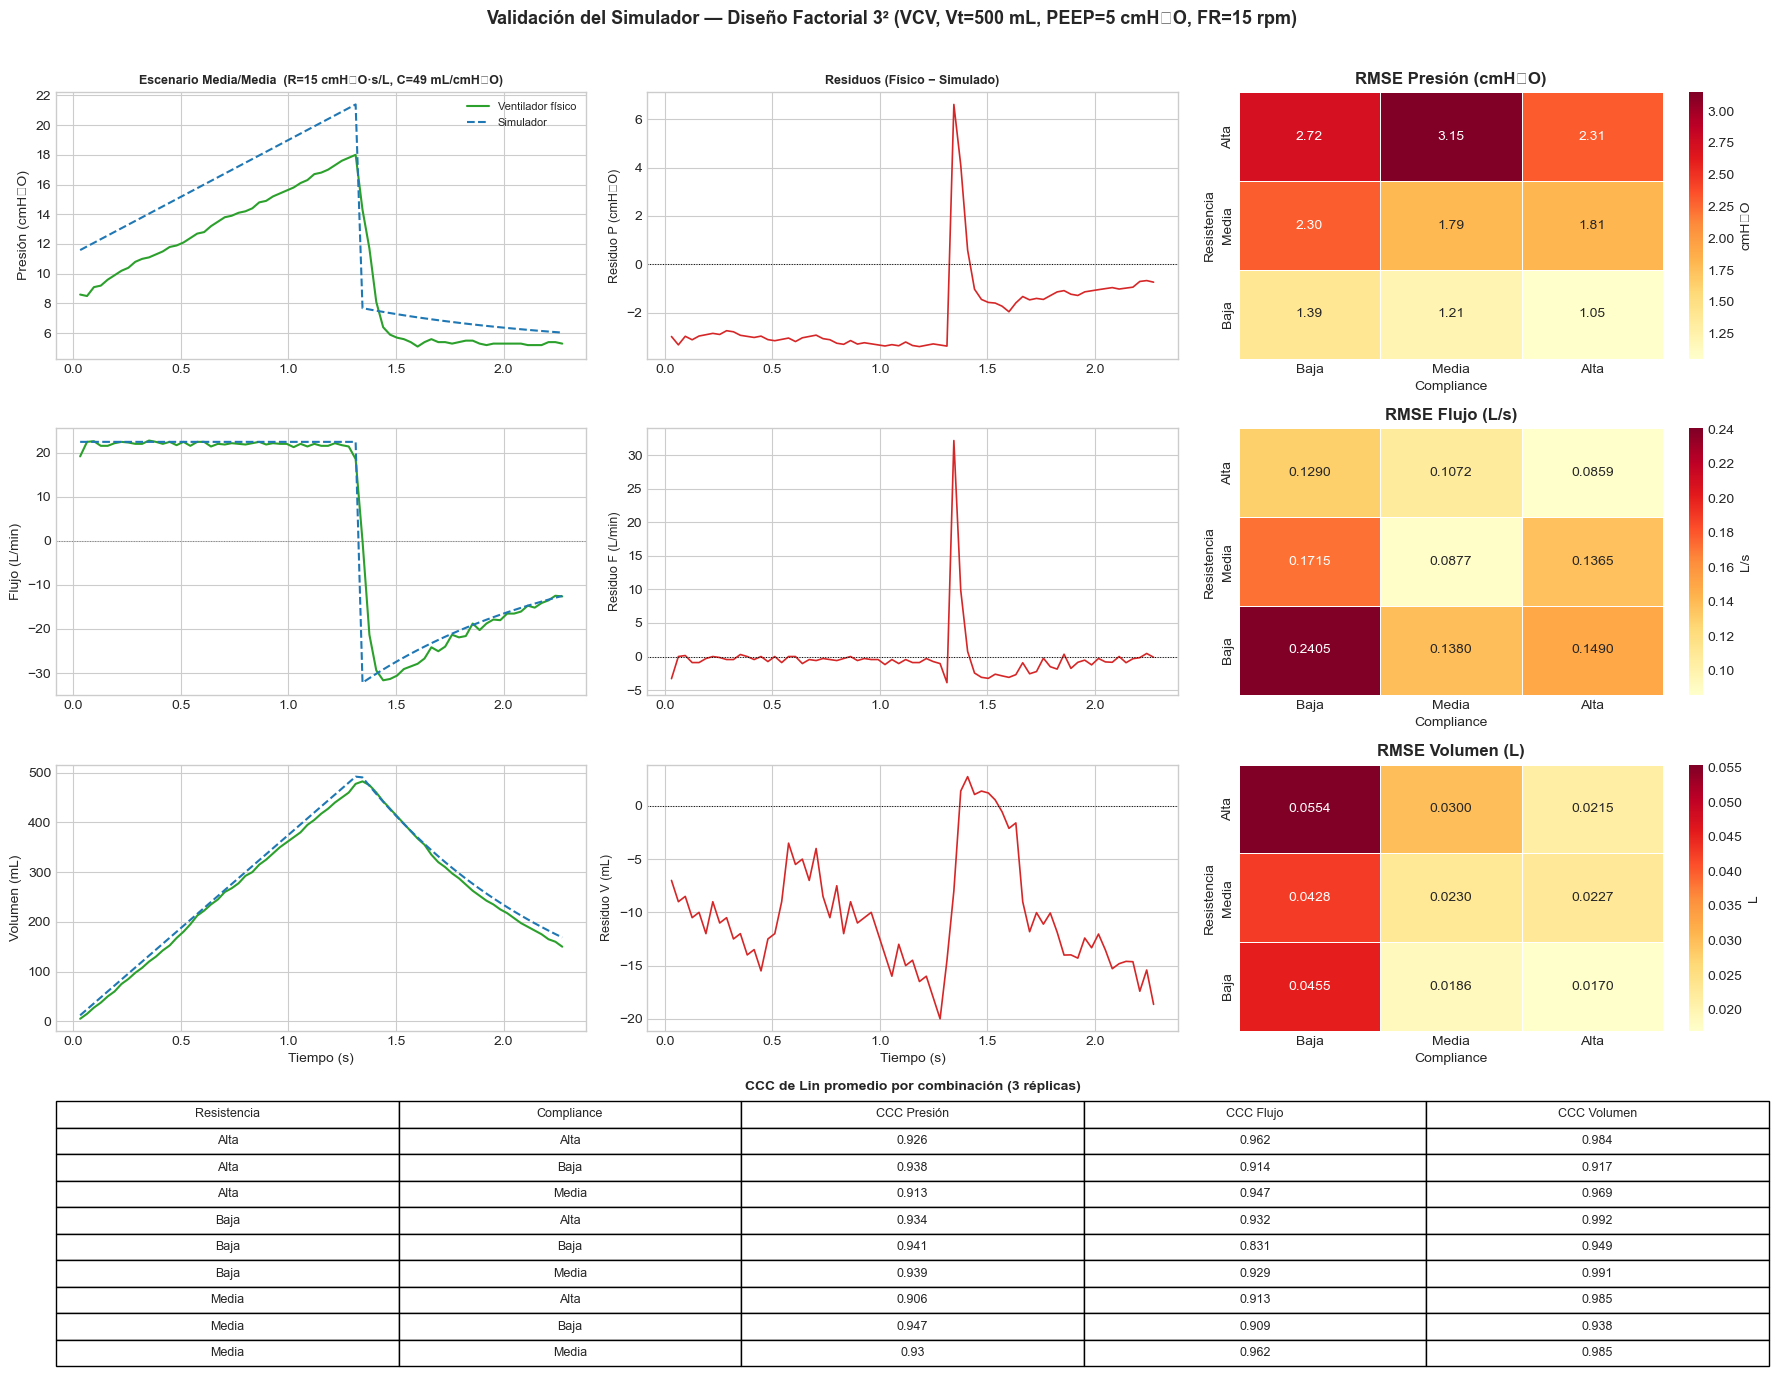

In [8]:
# ── Ordenamiento categórico para los ejes de los mapas de calor ────────────
ORD_R = ['Alta', 'Media', 'Baja']    # y-axis: R descendente
ORD_C = ['Baja', 'Media', 'Alta']    # x-axis: C ascendente

def heatmap_metrica(ax, df, col, titulo, cmap, fmt, label_cb):
    piv = (df.groupby(['Resistencia', 'Compliance'])[col]
             .mean()
             .reset_index()
             .pivot(index='Resistencia', columns='Compliance', values=col)
             .reindex(index=ORD_R, columns=ORD_C))
    sns.heatmap(piv, annot=True, cmap=cmap, fmt=fmt, ax=ax,
                cbar_kws={'label': label_cb}, linewidths=0.5)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Compliance')
    ax.set_ylabel('Resistencia')

# ── Dashboard 1: Series de tiempo (escenario Media/Media) + mapas RMSE ─────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Validación del Simulador — Diseño Factorial 3² (VCV, Vt=500 mL, PEEP=5 cmH₂O, FR=15 rpm)',
             fontsize=13, fontweight='bold', y=0.98)

# Colores
COL_FIS = '#2ca02c'   # verde: ventilador físico
COL_SIM = '#1f77b4'   # azul: simulador

d = datos_ejemplo
R_ej = d['R']
C_ej = d['C']
titulo_ej = f'Escenario Media/Media  (R={R_ej} cmH₂O·s/L, C={C_ej} mL/cmH₂O)'

# — Columna izquierda: series de tiempo P / F / V ——————————————————————————
ax_P = fig.add_subplot(4, 3, 1)
ax_F = fig.add_subplot(4, 3, 4, sharex=ax_P)
ax_V = fig.add_subplot(4, 3, 7, sharex=ax_P)

ax_P.plot(d['t'], d['P_fis'], color=COL_FIS, lw=1.5, label='Ventilador físico')
ax_P.plot(d['t'], d['P_sim'], color=COL_SIM, lw=1.5, ls='--', label='Simulador')
ax_P.set_ylabel('Presión (cmH₂O)')
ax_P.legend(fontsize=8)
ax_P.set_title(titulo_ej, fontweight='bold', fontsize=9)

ax_F.plot(d['t'], d['F_fis'] * 60, color=COL_FIS, lw=1.5)   # L/s → L/min para legibilidad
ax_F.plot(d['t'], d['F_sim'] * 60, color=COL_SIM, lw=1.5, ls='--')
ax_F.axhline(0, color='grey', lw=0.7, ls=':')
ax_F.set_ylabel('Flujo (L/min)')

ax_V.plot(d['t'], d['V_fis'] * 1000, color=COL_FIS, lw=1.5)  # L → mL
ax_V.plot(d['t'], d['V_sim'] * 1000, color=COL_SIM, lw=1.5, ls='--')
ax_V.set_ylabel('Volumen (mL)')
ax_V.set_xlabel('Tiempo (s)')

# — Columna central: residuos P / F / V ————————————————————————————————————
ax_rP = fig.add_subplot(4, 3, 2, sharex=ax_P)
ax_rF = fig.add_subplot(4, 3, 5, sharex=ax_P)
ax_rV = fig.add_subplot(4, 3, 8, sharex=ax_P)
COL_RES = '#d62728'

for ax_r, y_fis, y_sim, ylabel in [
    (ax_rP, d['P_fis'],        d['P_sim'],        'Residuo P (cmH₂O)'),
    (ax_rF, d['F_fis'] * 60,  d['F_sim'] * 60,  'Residuo F (L/min)'),
    (ax_rV, d['V_fis'] * 1000, d['V_sim'] * 1000, 'Residuo V (mL)'),
]:
    ax_r.plot(d['t'], y_fis - y_sim, color=COL_RES, lw=1.2)
    ax_r.axhline(0, color='black', lw=0.7, ls=':')
    ax_r.set_ylabel(ylabel, fontsize=9)

ax_rP.set_title('Residuos (Físico − Simulado)', fontweight='bold', fontsize=9)
ax_rV.set_xlabel('Tiempo (s)')

# — Columna derecha: mapas de calor RMSE ———————————————————————————————————
ax_hP = fig.add_subplot(4, 3, 3)
ax_hF = fig.add_subplot(4, 3, 6)
ax_hV = fig.add_subplot(4, 3, 9)

heatmap_metrica(ax_hP, df_res, 'RMSE_P', 'RMSE Presión (cmH₂O)',  'YlOrRd', '.2f', 'cmH₂O')
heatmap_metrica(ax_hF, df_res, 'RMSE_F', 'RMSE Flujo (L/s)',       'YlOrRd', '.4f', 'L/s')
heatmap_metrica(ax_hV, df_res, 'RMSE_V', 'RMSE Volumen (L)',        'YlOrRd', '.4f', 'L')

# — Fila inferior: tabla CCC promedio por combinación ——————————————————————
ax_tab = fig.add_subplot(4, 1, 4)
ax_tab.axis('off')

ccc_tabla = (df_res.groupby(['Resistencia', 'Compliance'])[['CCC_P', 'CCC_F', 'CCC_V']]
                   .mean()
                   .round(3)
                   .reset_index())
ccc_tabla.columns = ['Resistencia', 'Compliance', 'CCC Presión', 'CCC Flujo', 'CCC Volumen']

table = ax_tab.table(
    cellText=ccc_tabla.values,
    colLabels=ccc_tabla.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
ax_tab.set_title('CCC de Lin promedio por combinación (3 réplicas)',
                 fontweight='bold', fontsize=10, pad=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


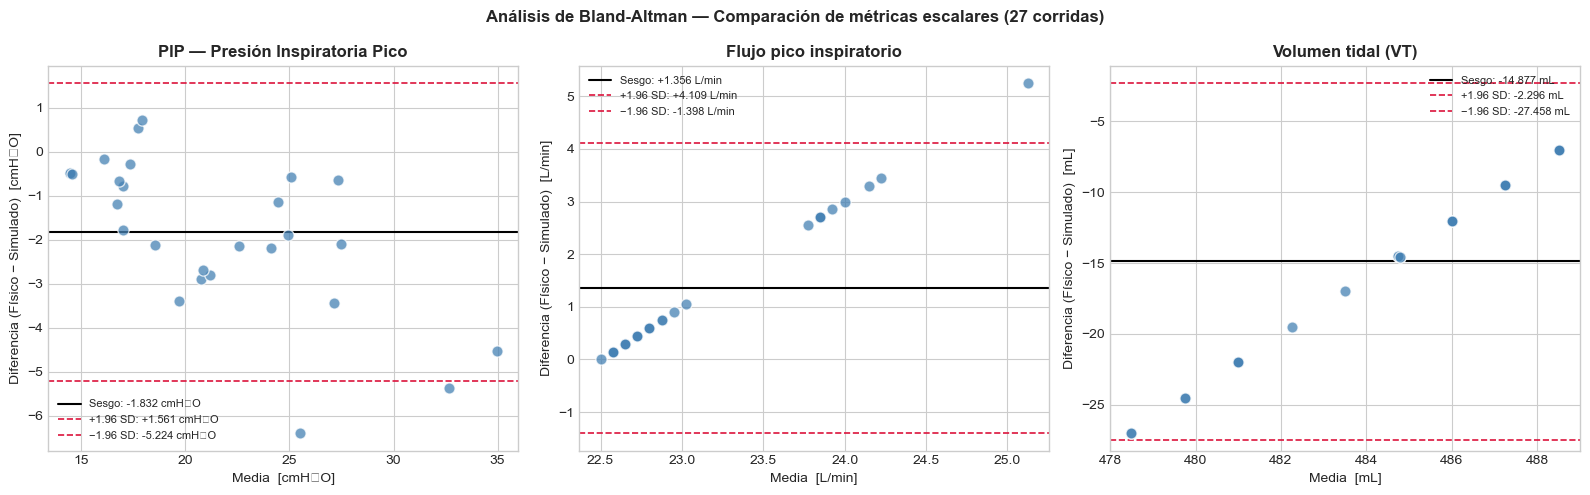


── RMSE y CCC medios por combinación ─────────────────────────────────
                        RMSE_P  RMSE_F  RMSE_V   CCC_P   CCC_F   CCC_V
Resistencia Compliance                                                
Alta        Baja        2.7193  0.1290  0.0554  0.9383  0.9141  0.9167
            Media       3.1488  0.1072  0.0300  0.9131  0.9468  0.9685
            Alta        2.3107  0.0859  0.0215  0.9261  0.9617  0.9845
Media       Baja        2.3003  0.1715  0.0428  0.9472  0.9087  0.9377
            Media       1.7914  0.0877  0.0230  0.9303  0.9621  0.9847
            Alta        1.8114  0.1365  0.0227  0.9062  0.9134  0.9847
Baja        Baja        1.3913  0.2405  0.0455  0.9413  0.8310  0.9485
            Media       1.2129  0.1380  0.0186  0.9388  0.9287  0.9914
            Alta        1.0520  0.1490  0.0170  0.9342  0.9315  0.9920


In [9]:
# ── Dashboard 2: Bland-Altman sobre las tres métricas escalares ─────────────
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Análisis de Bland-Altman — Comparación de métricas escalares (27 corridas)',
              fontsize=12, fontweight='bold')

def bland_altman(ax, fis, sim, titulo, unidad):
    medias  = (np.asarray(fis) + np.asarray(sim)) / 2.0
    difs    = np.asarray(fis) - np.asarray(sim)
    sesgo   = np.mean(difs)
    sd      = np.std(difs, ddof=1)
    loa_sup = sesgo + 1.96 * sd
    loa_inf = sesgo - 1.96 * sd

    ax.scatter(medias, difs, color='steelblue', alpha=0.75,
               edgecolors='white', s=65, zorder=3)
    ax.axhline(sesgo,   color='black',   lw=1.5,
               label=f'Sesgo: {sesgo:+.3f} {unidad}')
    ax.axhline(loa_sup, color='crimson', lw=1.2, ls='--',
               label=f'+1.96 SD: {loa_sup:+.3f} {unidad}')
    ax.axhline(loa_inf, color='crimson', lw=1.2, ls='--',
               label=f'−1.96 SD: {loa_inf:+.3f} {unidad}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(f'Media  [{unidad}]')
    ax.set_ylabel(f'Diferencia (Físico − Simulado)  [{unidad}]')
    ax.legend(fontsize=8)

bland_altman(axes[0],
             df_res['PIP_fis'],    df_res['PIP_sim'],
             'PIP — Presión Inspiratoria Pico', 'cmH₂O')

bland_altman(axes[1],
             df_res['Qpico_fis'] * 60, df_res['Qpico_sim'] * 60,
             'Flujo pico inspiratorio', 'L/min')

bland_altman(axes[2],
             df_res['VT_fis'] * 1000, df_res['VT_sim'] * 1000,
             'Volumen tidal (VT)', 'mL')

plt.tight_layout()
plt.show()

# ── Tabla resumen final ──────────────────────────────────────────────────────
print("\n── RMSE y CCC medios por combinación ─────────────────────────────────")
resumen = (df_res.groupby(['Resistencia', 'Compliance'])
                 [['RMSE_P', 'RMSE_F', 'RMSE_V', 'CCC_P', 'CCC_F', 'CCC_V']]
                 .mean()
                 .round(4))
print(resumen.reindex([(r, c) for r in ORD_R for c in ORD_C]).to_string())